<a href="https://colab.research.google.com/github/jrdndj/ImproVisAR-PilotPlots/blob/main/Study3_keypress_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-2-c766e761f14e>:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_changes = df.groupby(['Condition', 'Task', 'Participant']).apply(calculate_pct_change)


1. Overall Engagement Statistics:
                Keypresses              
                      mean     std count
Condition Task                          
AR        Task1    1560.33  956.02     6
          Task2     879.83  447.99     6
Sheets    Task1    1097.83   67.57     6
          Task2     767.67  225.24     6

2. Percentage Changes by Condition and Task:
                  mean    std
Condition Task               
AR        Task1 -13.26  47.91
          Task2  -8.72  49.58
Sheets    Task1   2.85  12.92
          Task2  -8.03  38.19

3. Individual Participant Changes:
Condition       AR        Sheets       
Task         Task1  Task2  Task1  Task2
Participant                            
T001         20.75  28.44    NaN    NaN
T002           NaN    NaN  -5.65  -1.63
T003          7.52  10.42    NaN    NaN
T004           NaN    NaN  17.72 -49.00
T005        -68.05 -65.02    NaN    NaN
T006           NaN    NaN  -3.52  26.56

4. Statistical Tests (Wilcoxon signed-rank test):
AR - T

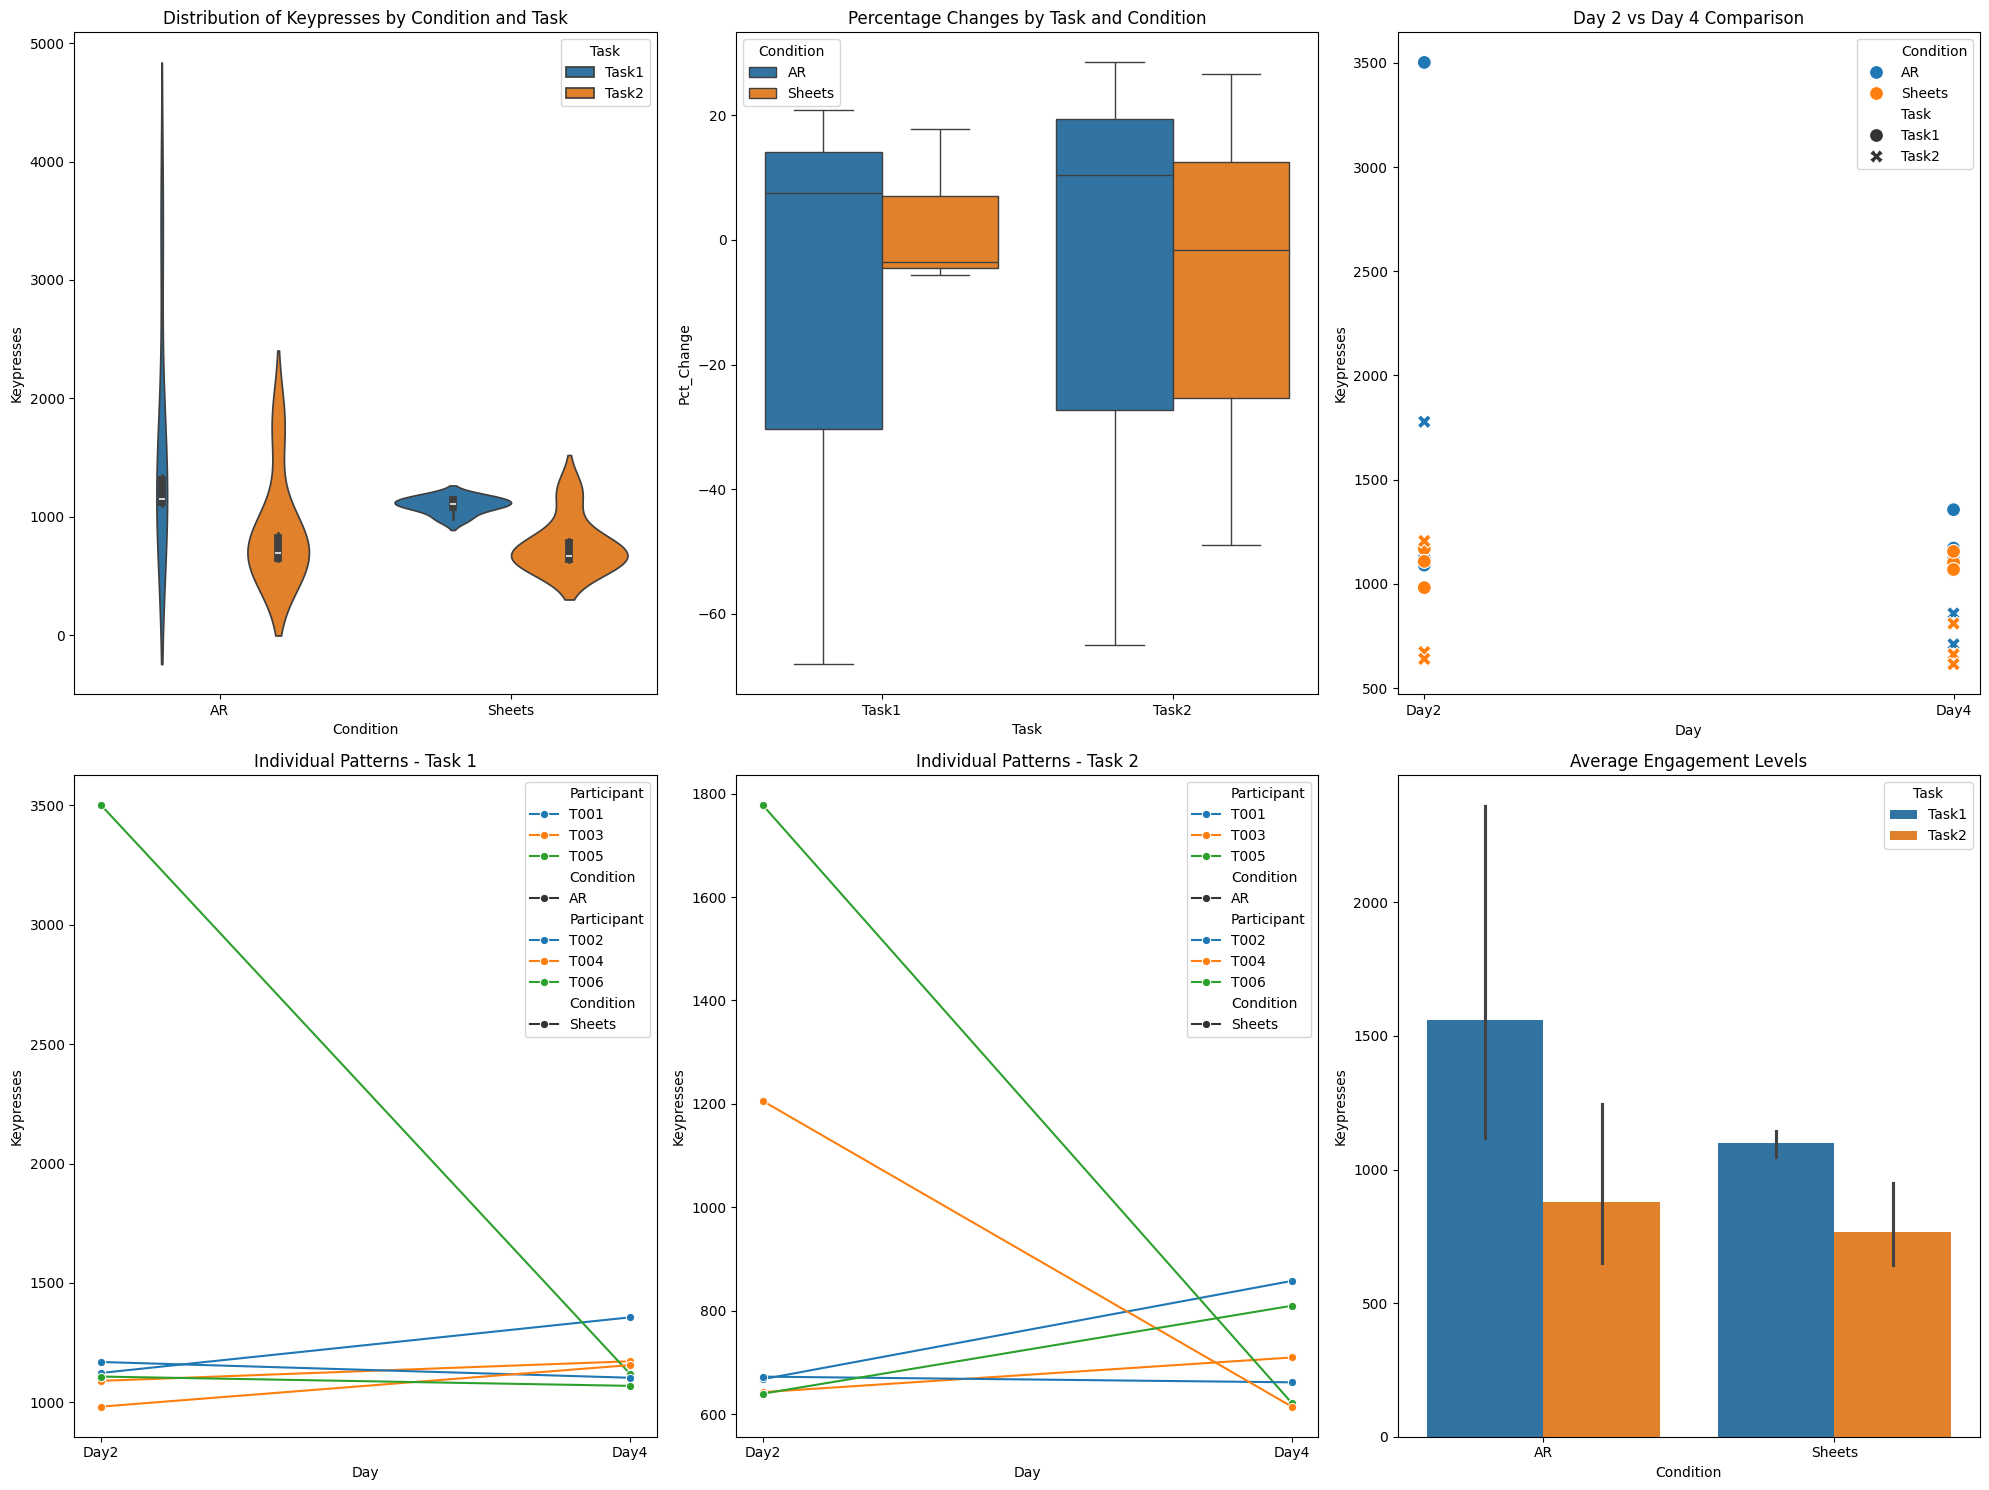

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Create structured data
data = []
for row in [
    # AR Condition Task 1
    ('AR', 'Task1', 'T001', 'Day2', 1123), ('AR', 'Task1', 'T001', 'Day4', 1356),
    ('AR', 'Task1', 'T003', 'Day2', 1090), ('AR', 'Task1', 'T003', 'Day4', 1172),
    ('AR', 'Task1', 'T005', 'Day2', 3502), ('AR', 'Task1', 'T005', 'Day4', 1119),
    # AR Condition Task 2
    ('AR', 'Task2', 'T001', 'Day2', 668), ('AR', 'Task2', 'T001', 'Day4', 858),
    ('AR', 'Task2', 'T003', 'Day2', 643), ('AR', 'Task2', 'T003', 'Day4', 710),
    ('AR', 'Task2', 'T005', 'Day2', 1778), ('AR', 'Task2', 'T005', 'Day4', 622),
    # Sheets Condition Task 1
    ('Sheets', 'Task1', 'T002', 'Day2', 1169), ('Sheets', 'Task1', 'T002', 'Day4', 1103),
    ('Sheets', 'Task1', 'T004', 'Day2', 982), ('Sheets', 'Task1', 'T004', 'Day4', 1156),
    ('Sheets', 'Task1', 'T006', 'Day2', 1108), ('Sheets', 'Task1', 'T006', 'Day4', 1069),
    # Sheets Condition Task 2
    ('Sheets', 'Task2', 'T002', 'Day2', 673), ('Sheets', 'Task2', 'T002', 'Day4', 662),
    ('Sheets', 'Task2', 'T004', 'Day2', 1206), ('Sheets', 'Task2', 'T004', 'Day4', 615),
    ('Sheets', 'Task2', 'T006', 'Day2', 640), ('Sheets', 'Task2', 'T006', 'Day4', 810),
]:
    data.append({
        'Condition': row[0],
        'Task': row[1],
        'Participant': row[2],
        'Day': row[3],
        'Keypresses': row[4]
    })

df = pd.DataFrame(data)

# Calculate percentage changes
def calculate_pct_change(group):
    return ((group[group['Day'] == 'Day4']['Keypresses'].iloc[0] -
             group[group['Day'] == 'Day2']['Keypresses'].iloc[0]) /
             group[group['Day'] == 'Day2']['Keypresses'].iloc[0] * 100)

pct_changes = df.groupby(['Condition', 'Task', 'Participant']).apply(calculate_pct_change)
pct_changes = pct_changes.reset_index()
pct_changes.columns = ['Condition', 'Task', 'Participant', 'Pct_Change']

# Create visualizations
plt.figure(figsize=(20, 15))

# Plot 1: Overall keypresses distribution
plt.subplot(231)
sns.violinplot(data=df, x='Condition', y='Keypresses', hue='Task')
plt.title('Distribution of Keypresses by Condition and Task')

# Plot 2: Percentage changes
plt.subplot(232)
sns.boxplot(data=pct_changes, x='Task', y='Pct_Change', hue='Condition')
plt.title('Percentage Changes by Task and Condition')

# Plot 3: Day 2 vs Day 4 comparison
plt.subplot(233)
sns.scatterplot(data=df, x='Day', y='Keypresses', hue='Condition',
                style='Task', s=100)
plt.title('Day 2 vs Day 4 Comparison')

# Plot 4: Individual participant patterns - Task 1
plt.subplot(234)
for condition in ['AR', 'Sheets']:
    task1_data = df[(df['Task'] == 'Task1') & (df['Condition'] == condition)]
    sns.lineplot(data=task1_data, x='Day', y='Keypresses',
                hue='Participant', style='Condition', marker='o')
plt.title('Individual Patterns - Task 1')

# Plot 5: Individual participant patterns - Task 2
plt.subplot(235)
for condition in ['AR', 'Sheets']:
    task2_data = df[(df['Task'] == 'Task2') & (df['Condition'] == condition)]
    sns.lineplot(data=task2_data, x='Day', y='Keypresses',
                hue='Participant', style='Condition', marker='o')
plt.title('Individual Patterns - Task 2')

# Plot 6: Overall engagement levels
plt.subplot(236)
sns.barplot(data=df, x='Condition', y='Keypresses', hue='Task')
plt.title('Average Engagement Levels')

plt.tight_layout()

# Statistical Analysis
stats_by_group = df.groupby(['Condition', 'Task']).agg({
    'Keypresses': ['mean', 'std', 'count']
}).round(2)

# Perform statistical tests
def run_stats_tests(data, condition, task):
    day2 = data[(data['Condition'] == condition) &
                (data['Task'] == task) &
                (data['Day'] == 'Day2')]['Keypresses']
    day4 = data[(data['Condition'] == condition) &
                (data['Task'] == task) &
                (data['Day'] == 'Day4')]['Keypresses']
    return stats.wilcoxon(day2, day4)

# Print comprehensive results
print("1. Overall Engagement Statistics:")
print(stats_by_group)
print("\n2. Percentage Changes by Condition and Task:")
print(pct_changes.groupby(['Condition', 'Task'])['Pct_Change'].agg(['mean', 'std']).round(2))
print("\n3. Individual Participant Changes:")
pivot_table = pct_changes.pivot_table(
    index='Participant',
    columns=['Condition', 'Task'],
    values='Pct_Change'
).round(2)
print(pivot_table)

# Statistical test results
conditions = ['AR', 'Sheets']
tasks = ['Task1', 'Task2']
print("\n4. Statistical Tests (Wilcoxon signed-rank test):")
for condition in conditions:
    for task in tasks:
        stat, p = run_stats_tests(df, condition, task)
        print(f"{condition} - {task}: p-value = {p:.4f}")